In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path().cwd() / "Data-LI"
LI_ACCOUNT_DATA_PATH = DATA_DIR / "LI-Small_accounts.csv"
LI_TRANSACTIONS_DATA_PATH = DATA_DIR / "LI-Small_Trans.csv"

accounts_df = pd.read_csv(LI_ACCOUNT_DATA_PATH)
trans_df = pd.read_csv(LI_TRANSACTIONS_DATA_PATH)

In [4]:
print(trans_df.shape)
print(accounts_df.shape)

(6924049, 13)
(712688, 6)


In [ ]:
trans_df['Timestamp'] = pd.to_datetime(trans_df['Timestamp'])
trans_df = trans_df.rename(columns={'Account':'From Account', 'Account.1':'To Account'})
accounts_df = accounts_df.rename(columns={'Account Number': 'Account'})

accounts_df['Universal_Account_ID'] = accounts_df['Bank ID'].astype(str) + "_" + accounts_df['Account'].astype(str)
trans_df['From_Universal_ID'] = trans_df['From Bank'].astype(str) + "_" + trans_df['From Account'].astype(str)
trans_df['To_Universal_ID'] = trans_df['To Bank'].astype(str) + "_" + trans_df['To Account'].astype(str)

trans_df = trans_df.sort_values(by=['From_Universal_ID', 'Timestamp']).reset_index(drop=True)

In [4]:
from feature_engine.datetime import DatetimeFeatures

dtf = DatetimeFeatures(
    variables="Timestamp",
    features_to_extract=["month", "day_of_week", "hour", "weekend"],
    drop_original=False 
)

trans_df = dtf.fit_transform(trans_df)

In [6]:
temp_df = trans_df.set_index('Timestamp')

roll_acc_24h = temp_df.groupby('From_Universal_ID')['Amount Paid'].rolling('24h').agg(['sum', 'count']).reset_index()

roll_acc_24h = roll_acc_24h.rename(columns={
    'sum': 'acc_vol_24h',
    'count': 'acc_count_24h'
})

roll_acc_24h = roll_acc_24h.drop_duplicates(subset=['From_Universal_ID', 'Timestamp'], keep='last')

trans_df = trans_df.merge(roll_acc_24h, on=['From_Universal_ID', 'Timestamp'], how='left')

In [7]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

df_ts = trans_df[['From_Universal_ID', 'Timestamp', 'Amount Paid']].copy()

features_ts = extract_features(
    df_ts, 
    column_id="From_Universal_ID", 
    column_sort="Timestamp",
    default_fc_parameters=MinimalFCParameters(),
    disable_progressbar=False
)

features_ts = pd.DataFrame(features_ts)

features_ts.columns = [f"tsfresh_{col}" for col in features_ts.columns]

trans_df = trans_df.merge(features_ts, left_on='From_Universal_ID', right_index=True, how='left')

Feature Extraction: 100%|██████████| 20/20 [04:48<00:00, 14.43s/it]


In [8]:
model_features = [
    'Amount Paid', 'Amount Received',
    'Timestamp_month', 'Timestamp_day_of_week', 'Timestamp_hour', 'Timestamp_weekend',
    'acc_vol_24h', 'acc_count_24h',
    'tsfresh_Amount Paid__sum_values', 'tsfresh_Amount Paid__variance', 
    'tsfresh_Amount Paid__maximum', 'tsfresh_Amount Paid__mean'
]

X = trans_df[model_features]

y_real = trans_df['Is Laundering']

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100, 
    contamination=0.005,
    random_state=42, 
    n_jobs=-1
)

trans_df['anomaly_label'] = iso.fit_predict(X)
trans_df['anomaly_score'] = iso.decision_function(X)

trans_df['pred_laundering'] = trans_df['anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

Confusion matrix:
[[6851319   69165]
 [   3489      76]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   6920484
           1       0.00      0.02      0.00      3565

    accuracy                           0.99   6924049
   macro avg       0.50      0.51      0.50   6924049
weighted avg       1.00      0.99      0.99   6924049



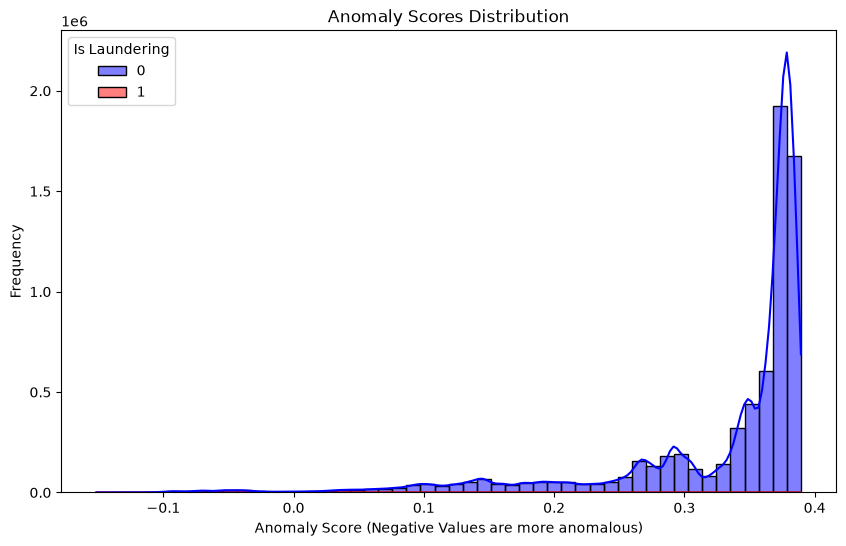

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Confusion matrix:")
print(confusion_matrix(y_real, trans_df['pred_laundering']))
print("\nClassification report:")
print(classification_report(y_real, trans_df['pred_laundering']))

plt.figure(figsize=(10, 6))
sns.histplot(
    data=trans_df, 
    x='anomaly_score', 
    hue='Is Laundering', 
    bins=50, 
    kde=True,
    palette={0: 'blue', 1: 'red'}
)
plt.title('Anomaly Scores Distribution')
plt.xlabel('Anomaly Score (Negative Values are more anomalous)')
plt.ylabel('Frequency')
plt.show()

### Novos pontos a aprender

- Estudar a lib Category Encoders para ver se ela pode ser de alguma ajuda
- Continuar treinando as implementações de agregações manuais com o Pandas 
- Testar novas bibliotecas e ferramentas como Polars, DBT, Pyspark, Feature Stores e processamento em streaming (como Apache Kafka e Flink), para necessidades futuras de alta performance em produção. 
- Explorar novos conceitos como  Análise de Grafos e Graph ML e pesquisar sobre Autoencoders
- Modelos Avançados Não Supervisionados como Local Outlier Factor (LOF) e One-Class SVM